In [1]:
# Cargamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Cargamos el dataset
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/Mall_Customers.csv")  # Modificar según ruta donde se almacene

print(df.head()) # Los datos cargaron correctamente


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# Moddificamos el df
df = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [5]:
df.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


En este caso, n es reducido, solo 200 entradas y las variables presentan desviaciones estándar muy similares, por lo que no es necesario normalizar.

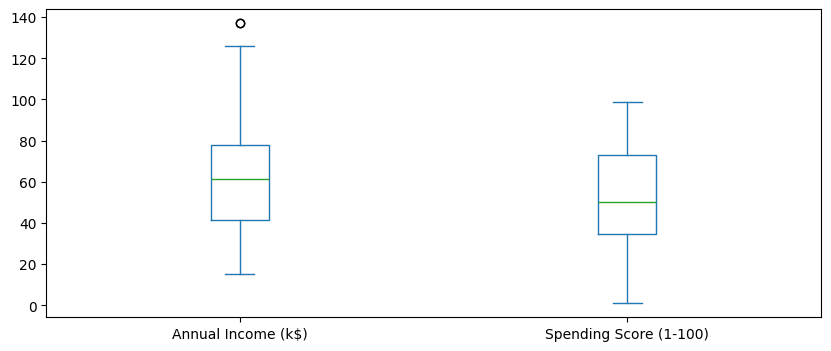

In [6]:
df.plot.box(figsize=(10,4))
plt.show()

Observamos que no hay outliers y las variables presentan cierta dispersión.


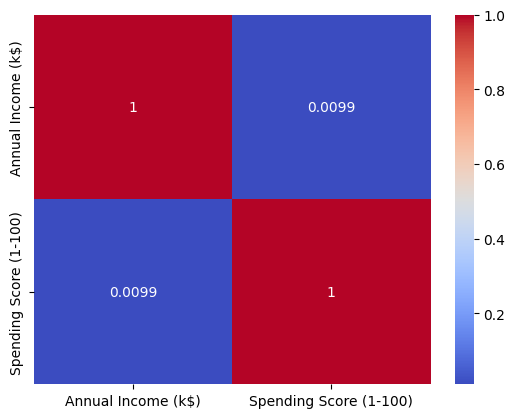

In [7]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

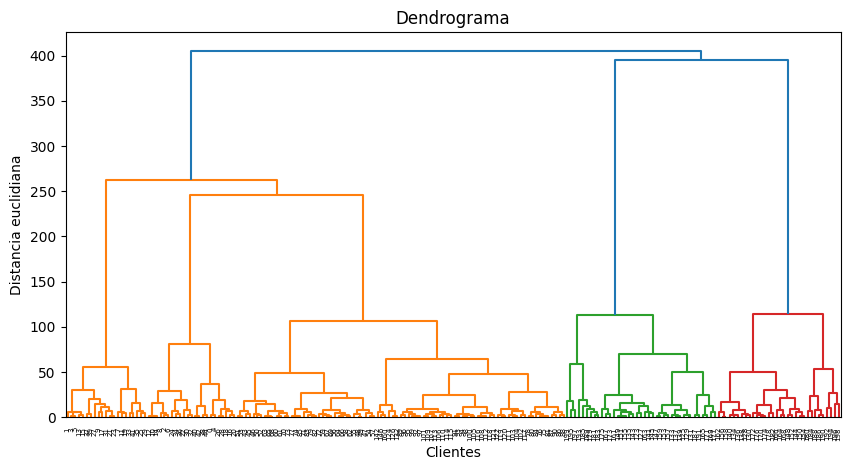

In [8]:
# Realizamos el Dendrograma
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(df, method='ward'))
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancia euclidiana')
plt.show()

Observamos que se pueden diferenciar 3 clústeres.

In [9]:
# Entrenamos el modelo con 3 clusters
clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward').fit(df)
df['cluster'] = clustering.labels_ # Añadimos los clusteres

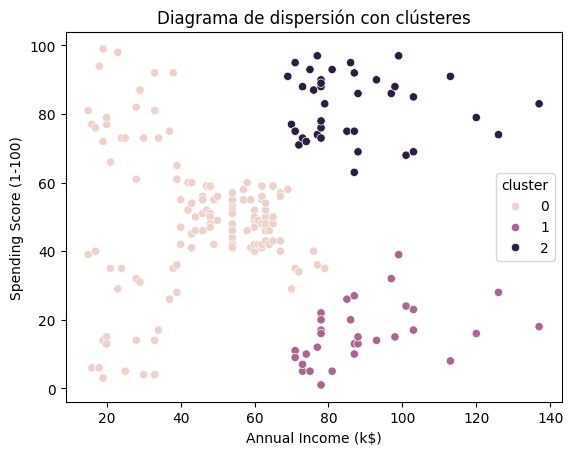

In [10]:
# Visualizamos los clusteres
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster")
plt.title("Diagrama de dispersión con clústeres")
plt.show()

Los clusteres quedan separados a simple vista.